### 实验05：检测下限测试

#### 实验内容
1. 微小力值检测能力测试
2. 基于信噪比（SNR）的检测下限计算
3. 基于3σ准则的检测下限确定
4. 力分辨率计算

#### 输入数据说明
- 文件格式：CSV，三列数据（Time_ms, RawValue, RawGround）
- 文件夹结构：主路径下包含 0, 1, 2, ... 编号子文件夹
- 每个子文件夹包含**一个**CSV文件
- 力值（微小力N）由用户在配置中指定
- 第一个文件夹(编号0)应为零负载基准数据

#### 1. 导入库与参数配置

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import os, glob, sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from plot_style import apply_measurement_style, COLORS, add_subplot_label, save_figure, SAVE_DIRS

apply_measurement_style()
SAVE_DIR = SAVE_DIRS[5]

V_REF = 5.0
LSB = V_REF / (2**15)

#### 2. 数据加载函数

In [2]:
def load_sensor_data(file_path):
    """加载传感器CSV数据"""
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    return df

def extract_stable_stats(df, start_ratio=0.2, end_ratio=0.8):
    """提取稳定区间的统计量"""
    n = len(df)
    start_idx = int(n * start_ratio)
    end_idx = int(n * end_ratio)
    stable_data = df['RawValue'].iloc[start_idx:end_idx].values
    return {
        'mean': np.mean(stable_data),
        'std': np.std(stable_data),
        'min': np.min(stable_data),
        'max': np.max(stable_data),
        'data': stable_data
    }

def get_csv_file_in_folder(folder_path):
    """获取文件夹内的CSV文件（假设只有一个）"""
    pattern = os.path.join(folder_path, "*.csv")
    files = glob.glob(pattern)
    files.sort()  # 按文件名排序
    return files[0] if files else None

#### 3. 配置数据路径与力值

In [3]:
_BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "workspace", "test5")
BASE_PATH = _BASE

FORCE_CONFIG = {
    "0":  0.0,    # zero load baseline
    "1":  0.05,   # 50 mN
    "2":  0.10,   # 100 mN
    "3":  0.20,   # 200 mN
    "4":  0.50,   # 500 mN
}

print(f"主路径: {BASE_PATH}")
print(f"配置的测试点数量: {len(FORCE_CONFIG)} (含零点)")

主路径: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\05_Detection_Limit_0.0\..\..\workspace\test5
配置的测试点数量: 5 (含零点)


#### 4. 自动扫描与加载数据

In [4]:
# 自动扫描文件夹并加载数据
all_data = {}

print("数据加载详情:")
print("="*70)

for folder_name, force_value in sorted(FORCE_CONFIG.items(), key=lambda x: x[1]):
    folder_path = os.path.join(BASE_PATH, folder_name)
    
    if not os.path.isdir(folder_path):
        print(f"✗ 文件夹不存在: {folder_path}")
        continue
    
    csv_file = get_csv_file_in_folder(folder_path)
    
    if csv_file is None:
        print(f"✗ 文件夹 {folder_name} 中没有CSV文件")
        continue
    
    df = load_sensor_data(csv_file)
    stats_data = extract_stable_stats(df)
    
    all_data[force_value] = {
        'folder': folder_name,
        'file': csv_file,
        'stats': stats_data
    }
    
    force_mN = force_value * 1000
    print(f"✓ 文件夹 {folder_name} ({force_mN:.1f} mN): {os.path.basename(csv_file)}")
    print(f"    均值={stats_data['mean']:.2f} LSB, σ={stats_data['std']:.3f} LSB")

print(f"\n共加载 {len(all_data)} 个测试点")

数据加载详情:
✓ 文件夹 0 (0.0 mN): Tactile_AD1_R0_C0_20251222_211632.csv
    均值=-5.21 LSB, σ=1.169 LSB
✓ 文件夹 1 (50.0 mN): Tactile_AD1_R0_C2_20251222_211559.csv
    均值=-71.19 LSB, σ=1.730 LSB
✓ 文件夹 2 (100.0 mN): Tactile_AD1_R0_C2_20251222_211010.csv
    均值=-116.79 LSB, σ=2.004 LSB
✓ 文件夹 3 (200.0 mN): Tactile_AD1_R0_C2_20251222_211133.csv
    均值=-226.76 LSB, σ=315.304 LSB
✓ 文件夹 4 (500.0 mN): Tactile_AD1_R0_C2_20251222_211412.csv
    均值=-574.81 LSB, σ=4.106 LSB

共加载 5 个测试点


#### 5. 零负载噪声基准

In [5]:
# 获取零负载数据
if 0.0 not in all_data:
    raise ValueError("错误: 没有找到零负载(0N)的数据!")

zero_stats = all_data[0.0]['stats']

noise_mean = zero_stats['mean']
noise_std = zero_stats['std']
noise_3sigma = 3 * noise_std

print("="*60)
print("【零负载噪声基准】")
print("="*60)
print(f"零点均值: {noise_mean:.3f} LSB")
print(f"噪声标准差 σ: {noise_std:.3f} LSB")
print(f"噪声 3σ: {noise_3sigma:.3f} LSB")
print(f"噪声 6σ (峰峰): {6*noise_std:.3f} LSB")

【零负载噪声基准】
零点均值: -5.206 LSB
噪声标准差 σ: 1.169 LSB
噪声 3σ: 3.507 LSB
噪声 6σ (峰峰): 7.014 LSB


#### 6. 微小力值检测测试

In [6]:
results = []

# 排除零点，只分析非零力值
nonzero_forces = sorted([f for f in all_data.keys() if f > 0])

for force in nonzero_forces:
    stats_data = all_data[force]['stats']
    
    # 信号变化量
    delta_S = stats_data['mean'] - noise_mean
    
    # 信噪比
    SNR = abs(delta_S) / noise_std if noise_std > 0 else np.inf
    SNR_dB = 20 * np.log10(SNR) if SNR > 0 else -np.inf
    
    # 是否可检测 (3σ准则)
    detectable = abs(delta_S) > noise_3sigma
    
    # t检验判断显著性
    t_stat, p_value = stats.ttest_ind(stats_data['data'], zero_stats['data'])
    significant = p_value < 0.001
    
    results.append({
        'Force_N': force,
        'Force_mN': force * 1000,
        'Mean_LSB': stats_data['mean'],
        'Std_LSB': stats_data['std'],
        'Delta_S_LSB': delta_S,
        'SNR': SNR,
        'SNR_dB': SNR_dB,
        'Detectable_3sigma': detectable,
        'p_value': p_value,
        'Significant': significant
    })

df_results = pd.DataFrame(results)

print("微小力值检测结果:")
print("-"*90)
print(df_results[['Force_mN', 'Delta_S_LSB', 'SNR', 'Detectable_3sigma', 'Significant']].to_string(index=False))

微小力值检测结果:
------------------------------------------------------------------------------------------
 Force_mN  Delta_S_LSB        SNR  Detectable_3sigma  Significant
     50.0   -65.988507  56.451747               True         True
    100.0  -111.580681  95.454869               True         True
    200.0  -221.549142 189.530520               True         True
    500.0  -569.599875 487.280426               True         True


#### 7. 检测下限确定

In [7]:
# 基于3σ准则的检测下限
detectable_forces = df_results[df_results['Detectable_3sigma']]['Force_N'].values
if len(detectable_forces) > 0:
    LOD_3sigma = detectable_forces.min()
else:
    LOD_3sigma = np.nan

# 基于统计显著性的检测下限
significant_forces = df_results[df_results['Significant']]['Force_N'].values
if len(significant_forces) > 0:
    LOD_stat = significant_forces.min()
else:
    LOD_stat = np.nan

# 基于灵敏度计算理论检测下限
# 使用最大力值点估算灵敏度
max_force = df_results['Force_N'].max()
max_force_delta = df_results[df_results['Force_N'] == max_force]['Delta_S_LSB'].values[0]
sensitivity = max_force_delta / max_force if max_force > 0 else 0  # LSB/N
LOD_theoretical = noise_3sigma / sensitivity if sensitivity > 0 else np.nan

print("="*60)
print("【检测下限（LOD）确定】")
print("="*60)
if not np.isnan(LOD_3sigma):
    print(f"基于3σ准则的检测下限: {LOD_3sigma*1000:.2f} mN ({LOD_3sigma:.4f} N)")
else:
    print("基于3σ准则: 所有测试力值均未达到检测阈值")

if not np.isnan(LOD_stat):
    print(f"基于统计显著性的检测下限: {LOD_stat*1000:.2f} mN ({LOD_stat:.4f} N)")
else:
    print("基于统计显著性: 所有测试力值均未达到显著性阈值")

if not np.isnan(LOD_theoretical):
    print(f"理论检测下限 (3σ/灵敏度): {LOD_theoretical*1000:.2f} mN ({LOD_theoretical:.4f} N)")
else:
    print("理论检测下限: 无法计算")

print()
print(f"灵敏度估计: {sensitivity:.2f} LSB/N")
print(f"噪声3σ: {noise_3sigma:.3f} LSB")

【检测下限（LOD）确定】
基于3σ准则的检测下限: 50.00 mN (0.0500 N)
基于统计显著性的检测下限: 50.00 mN (0.0500 N)
理论检测下限: 无法计算

灵敏度估计: -1139.20 LSB/N
噪声3σ: 3.507 LSB


#### 8. 可视化分析

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test5\png\05_detection_limit_overview.png


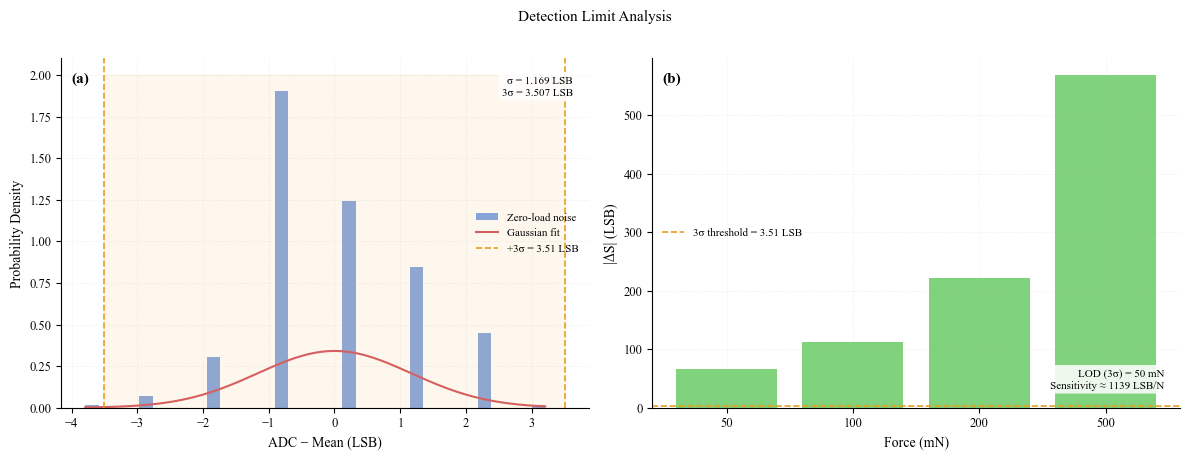

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test5\png\05a_noise_hist.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test5\png\05b_signal_change.png


In [8]:
# ── Fig 1: 2-panel detection limit ───────────────────────────────────────────
# (a) zero-load noise histogram + 3σ threshold line
# (b) array-point scale explanation (signal change vs force, SNR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Zero-load noise histogram + 3σ threshold
ax = axes[0]
zero_data = zero_stats['data'] - noise_mean
bins_z = np.linspace(zero_data.min(), zero_data.max(), 35)
ax.hist(zero_data, bins=bins_z, density=True,
        color=COLORS["zero"], alpha=0.65, edgecolor="none", label="Zero-load noise")
x_g = np.linspace(zero_data.min(), zero_data.max(), 200)
ax.plot(x_g, norm.pdf(x_g, 0, noise_std),
        color=COLORS["red"], linewidth=1.5, label="Gaussian fit")
ax.axvline( noise_3sigma, color=COLORS["orange"], linewidth=1.2, linestyle="--",
            label=f"+3σ = {noise_3sigma:.2f} LSB")
ax.axvline(-noise_3sigma, color=COLORS["orange"], linewidth=1.2, linestyle="--")
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                 -noise_3sigma, noise_3sigma,
                 color=COLORS["orange"], alpha=0.08)
ax.set_xlabel("ADC − Mean (LSB)"); ax.set_ylabel("Probability Density")
ax.text(0.97, 0.95, f"σ = {noise_std:.3f} LSB\n3σ = {noise_3sigma:.3f} LSB",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(a)")

# (b) Signal change vs force + SNR (log scale secondary)
ax = axes[1]
forces_mN = df_results['Force_mN'].values
delta_S   = df_results['Delta_S_LSB'].values
det_colors = [COLORS["detect"] if d else COLORS["red"]
              for d in df_results['Detectable_3sigma']]
ax.bar([f"{f:.0f}" for f in forces_mN], np.abs(delta_S),
       color=det_colors, edgecolor="none", alpha=0.85)
ax.axhline(noise_3sigma, color=COLORS["orange"], linewidth=1.2, linestyle="--",
           label=f"3σ threshold = {noise_3sigma:.2f} LSB")
ax.set_xlabel("Force (mN)"); ax.set_ylabel("|ΔS| (LSB)")
ax.text(0.97, 0.05,
        f"LOD (3σ) = {LOD_3sigma*1000:.0f} mN\nSensitivity ≈ {abs(sensitivity):.0f} LSB/N",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(b)")

fig.suptitle("Detection Limit Analysis", fontsize=11, y=1.01)
plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "05_detection_limit_overview")
print(f"Saved: {p}")
plt.show()

# ── Individual sub-figures ────────────────────────────────────────────────────
for i, stem in enumerate(["05a_noise_hist", "05b_signal_change"]):
    fig_s, ax_s = plt.subplots(figsize=(6, 4.5))
    if i == 0:
        ax_s.hist(zero_data, bins=bins_z, density=True,
                  color=COLORS["zero"], alpha=0.65, edgecolor="none")
        ax_s.plot(x_g, norm.pdf(x_g, 0, noise_std), color=COLORS["red"], linewidth=1.5)
        ax_s.axvline( noise_3sigma, color=COLORS["orange"], linewidth=1.2, linestyle="--")
        ax_s.axvline(-noise_3sigma, color=COLORS["orange"], linewidth=1.2, linestyle="--")
        ax_s.set_xlabel("ADC − Mean (LSB)"); ax_s.set_ylabel("Probability Density")
        ax_s.text(0.97, 0.95, f"σ = {noise_std:.3f} LSB\n3σ = {noise_3sigma:.3f} LSB",
                  transform=ax_s.transAxes, ha="right", va="top", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    else:
        ax_s.bar([f"{f:.0f}" for f in forces_mN], np.abs(delta_S),
                 color=det_colors, edgecolor="none", alpha=0.85)
        ax_s.axhline(noise_3sigma, color=COLORS["orange"], linewidth=1.2, linestyle="--")
        ax_s.set_xlabel("Force (mN)"); ax_s.set_ylabel("|ΔS| (LSB)")
        ax_s.text(0.97, 0.05,
                  f"LOD (3σ) = {LOD_3sigma*1000:.0f} mN\nSensitivity ≈ {abs(sensitivity):.0f} LSB/N",
                  transform=ax_s.transAxes, ha="right", va="bottom", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85))
    plt.tight_layout()
    p = save_figure(fig_s, SAVE_DIR, stem)
    print(f"Saved: {p}")
    plt.close(fig_s)

#### 9. 信号分布对比

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test5\png\05_distribution_comparison.png


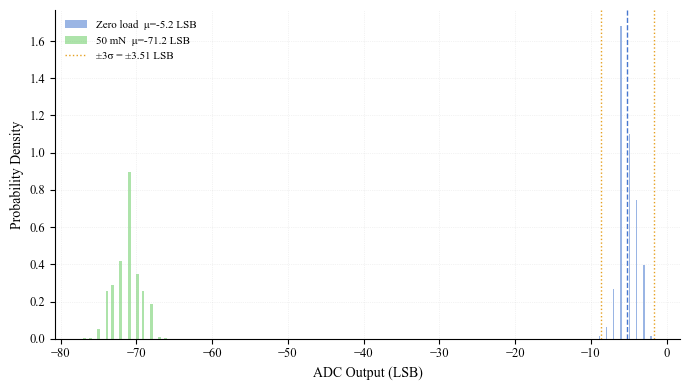

In [9]:
# Zero-load vs minimum detectable force distribution comparison
fig_d, ax_d = plt.subplots(figsize=(7, 4))

ax_d.hist(zero_stats['data'], bins=30, alpha=0.55, density=True,
          color=COLORS["zero"], edgecolor="none",
          label=f"Zero load  μ={noise_mean:.1f} LSB")

if not np.isnan(LOD_3sigma):
    min_stats = all_data[LOD_3sigma]['stats']
    ax_d.hist(min_stats['data'], bins=30, alpha=0.55, density=True,
              color=COLORS["detect"], edgecolor="none",
              label=f"{LOD_3sigma*1000:.0f} mN  μ={min_stats['mean']:.1f} LSB")

ax_d.axvline(noise_mean,              color=COLORS["zero"],   linewidth=1.0, linestyle="--")
ax_d.axvline(noise_mean + noise_3sigma, color=COLORS["orange"], linewidth=1.0, linestyle=":",
             label=f"±3σ = ±{noise_3sigma:.2f} LSB")
ax_d.axvline(noise_mean - noise_3sigma, color=COLORS["orange"], linewidth=1.0, linestyle=":")
ax_d.set_xlabel("ADC Output (LSB)"); ax_d.set_ylabel("Probability Density")
ax_d.legend(frameon=False, fontsize=8)
plt.tight_layout()
p = save_figure(fig_d, SAVE_DIR, "05_distribution_comparison")
print(f"Saved: {p}")
plt.show()

#### 10. 力分辨率计算

In [10]:
# 力分辨率定义为能够分辨的最小力值变化
# 通常取 1σ 对应的力值

force_resolution_1sigma = noise_std / sensitivity if sensitivity > 0 else np.nan
force_resolution_3sigma = noise_3sigma / sensitivity if sensitivity > 0 else np.nan

print("="*60)
print("【力分辨率】")
print("="*60)
if not np.isnan(force_resolution_1sigma):
    print(f"1σ 力分辨率: {force_resolution_1sigma*1000:.3f} mN")
    print(f"3σ 力分辨率: {force_resolution_3sigma*1000:.3f} mN")
else:
    print("无法计算力分辨率（灵敏度为零）")
print()
print("说明:")
print("  - 1σ分辨率表示68%置信度下可分辨的最小力变化")
print("  - 3σ分辨率表示99.7%置信度下可分辨的最小力变化")

【力分辨率】
无法计算力分辨率（灵敏度为零）

说明:
  - 1σ分辨率表示68%置信度下可分辨的最小力变化
  - 3σ分辨率表示99.7%置信度下可分辨的最小力变化


#### 11. 结果汇总

In [11]:
# 保存结果
df_results.to_csv('05_detection_limit_data.csv', index=False)

lod_params = {
    'Noise_Std_LSB': noise_std,
    'Noise_3sigma_LSB': noise_3sigma,
    'Sensitivity_LSB_per_N': sensitivity,
    'LOD_3sigma_N': LOD_3sigma if not np.isnan(LOD_3sigma) else None,
    'LOD_3sigma_mN': LOD_3sigma * 1000 if not np.isnan(LOD_3sigma) else None,
    'LOD_theoretical_N': LOD_theoretical if not np.isnan(LOD_theoretical) else None,
    'Resolution_1sigma_mN': force_resolution_1sigma * 1000 if not np.isnan(force_resolution_1sigma) else None,
    'Resolution_3sigma_mN': force_resolution_3sigma * 1000 if not np.isnan(force_resolution_3sigma) else None
}
pd.DataFrame([lod_params]).to_csv('05_detection_limit_params.csv', index=False)

# 显示结果
lod_3sigma_mN = LOD_3sigma * 1000 if not np.isnan(LOD_3sigma) else 0
lod_theo_mN = LOD_theoretical * 1000 if not np.isnan(LOD_theoretical) else 0
res_1sigma_mN = force_resolution_1sigma * 1000 if not np.isnan(force_resolution_1sigma) else 0
res_3sigma_mN = force_resolution_3sigma * 1000 if not np.isnan(force_resolution_3sigma) else 0

print("="*60)
print("【实验05 结果汇总】")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────────┐
│  检测下限测试结果                                       │
├─────────────────────────────────────────────────────────┤
│  测试力值点数:     {len(df_results):>10}                        │
│  噪声标准差 σ:     {noise_std:>10.3f} LSB                    │
│  灵敏度:           {sensitivity:>10.2f} LSB/N                  │
├─────────────────────────────────────────────────────────┤
│  检测下限 (3σ):    {lod_3sigma_mN:>10.2f} mN                     │
│  理论检测下限:     {lod_theo_mN:>10.2f} mN                     │
│  1σ 力分辨率:      {res_1sigma_mN:>10.3f} mN                    │
│  3σ 力分辨率:      {res_3sigma_mN:>10.3f} mN                    │
├─────────────────────────────────────────────────────────┤
│  文献参考值: 10 mN (0.01 N)                             │
└─────────────────────────────────────────────────────────┘
""")

print("检测下限数据已保存至: 05_detection_limit_data.csv")
print("检测下限参数已保存至: 05_detection_limit_params.csv")

【实验05 结果汇总】

┌─────────────────────────────────────────────────────────┐
│  检测下限测试结果                                       │
├─────────────────────────────────────────────────────────┤
│  测试力值点数:              4                        │
│  噪声标准差 σ:          1.169 LSB                    │
│  灵敏度:             -1139.20 LSB/N                  │
├─────────────────────────────────────────────────────────┤
│  检测下限 (3σ):         50.00 mN                     │
│  理论检测下限:           0.00 mN                     │
│  1σ 力分辨率:           0.000 mN                    │
│  3σ 力分辨率:           0.000 mN                    │
├─────────────────────────────────────────────────────────┤
│  文献参考值: 10 mN (0.01 N)                             │
└─────────────────────────────────────────────────────────┘

检测下限数据已保存至: 05_detection_limit_data.csv
检测下限参数已保存至: 05_detection_limit_params.csv
